In [29]:
import h5py
from os.path import join
import os
from scipy.spatial.transform.rotation import Rotation
import numpy as np
from matplotlib import pyplot
import cv2
import functools
from importlib import reload

In [30]:
from PIL import Image
from IPython.display import display

In [31]:
import vis
import utils
from datasets.preprocessing import imread, extract_image_roi, imencode, imdecode, labels_to_lists

In [32]:
reload(vis)

<module 'vis' from '/mnt/EigeneDateien/Programmierung/head-tracking/tracker-traincode/vis.py'>

In [4]:
import scripts.rotation_clusters as rotclustering

In [5]:
from datasets.dshdf5pose import Hdf5PoseDataset

In [6]:
# DATAFILENAME = '/media/mwelter/Stuff/head-tracking-datasets/vggface2decafit.h5'
# imagefolder = '/mnt/BigData/head-tracking-datasets/VGG-Face2/train/imgs/'
# with h5py.File(DATAFILENAME, 'r') as datafile:
#     rotvecs = np.asarray(datafile['fits/pose'][...,:3])
# quats = Rotation.from_rotvec(rotvecs).as_quat()

In [11]:
DATAFILENAME = '/media/mwelter/Stuff/head-tracking-datasets/vggface2-tracker.h5'
with h5py.File(DATAFILENAME, 'r') as datafile:
    quats = datafile['quats'][...]

In [12]:
labels = rotclustering.compute_clustering_by_quats(quats)

In [13]:
clusters = labels_to_lists(labels)
clusters = sorted(clusters, key = lambda c: len(c))

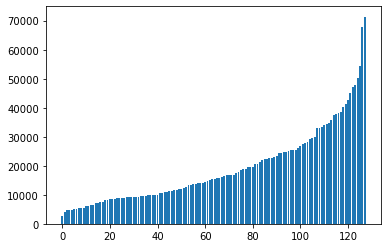

In [14]:
rotclustering.visualize_frequencies(clusters)

In [15]:
rotclustering.print_info(clusters)

Number of data points = 2449227
Times sampled / sweep | largest cluster  = 0.27
Times sampled / sweep | smallest cluster = 6.84
Ratio = 25.5



In [16]:
ds = Hdf5PoseDataset(DATAFILENAME)

In [17]:
functools.lru_cache(maxsize=1024)
def generate_sample(i,j):
    if i<0 or i>=len(clusters):
        return np.zeros((1,1,3), dtype=np.uint8)
    idx = clusters[i][j]
    sample = ds[idx]
    img = sample['image'].copy()
    vis._draw_sample(img, sample, False, False)
    return img

In [37]:
vis.display_image_panel_jupyter(generate_sample, 4, 7)